In [1]:
#Import libraries, load the dataset, and convert it into a DataFrame.

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Initial exploration of the dataset structure, shape, and missing values before any cleaning. 
# Lines commented out below were used for inspection and are kept for reference.

#df.head()
#df.tail()
#df.shape
#df.describe()
#df.info()
#df.isnull().sum()

# Data cleanup:
# - Convert job_posted_date from string to datetime.
# - Convert job_skills from a string representation of a list into an 
# actual Python list using ast.literal_eval, skipping NaN values.

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [2]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month'] = df_DA_US['job_posted_date'].dt.month

df_DA_US_explode = df_DA_US.explode('job_skills')

df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending= False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

In [3]:
df_DA_US_total = df_DA_US.groupby('job_posted_month').size()
df_DA_US_percent = df_DA_US_pivot.div(df_DA_US_total / 100, axis=0)

df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))

df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')

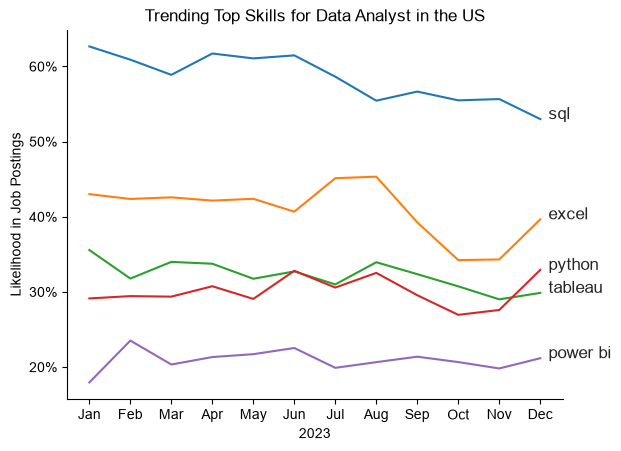

In [4]:
from matplotlib.ticker import PercentFormatter
df_plot = df_DA_US_percent.iloc[:,:5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analyst in the US')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Postings')
plt.legend().remove()

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
for i in range(5):
    plt.text(x=11.2, y=df_plot.iloc[-1, i], s=df_plot.columns[i])